In [5]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import struct

import funciones_aux as fau

import funciones_dsa as fun_dsa


from matplotlib.colors import LinearSegmentedColormap, PowerNorm

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr


# OG

#### Archivo f_a

In [9]:
ruta_base_advanced = "../data/data_bis_advanced"

archivos_fa = fau.localizar_archivos(ruta_base_advanced, "DH*", "*.f_a")
ruta_fa = archivos_fa[0]
print("Archivo seleccionado:", ruta_fa)

tiempo_fa_unilat, dsa_unilat = fau.cargar_fa_directo(ruta_fa, escalar_db=True)

print("Dimensiones de la matriz:", dsa_unilat.shape)
print("Frecuencias:", dsa_unilat.columns.min(), "a", dsa_unilat.columns.max(), "Hz")

Se han encontrado 2 archivos *.f_a
Archivo seleccionado: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a
Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz


#### Archivo spa

In [10]:
ruta_spa_unilat = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"
df_spa_unilat = fau.procesar_spa(ruta_spa_unilat)

## Unión de los 2

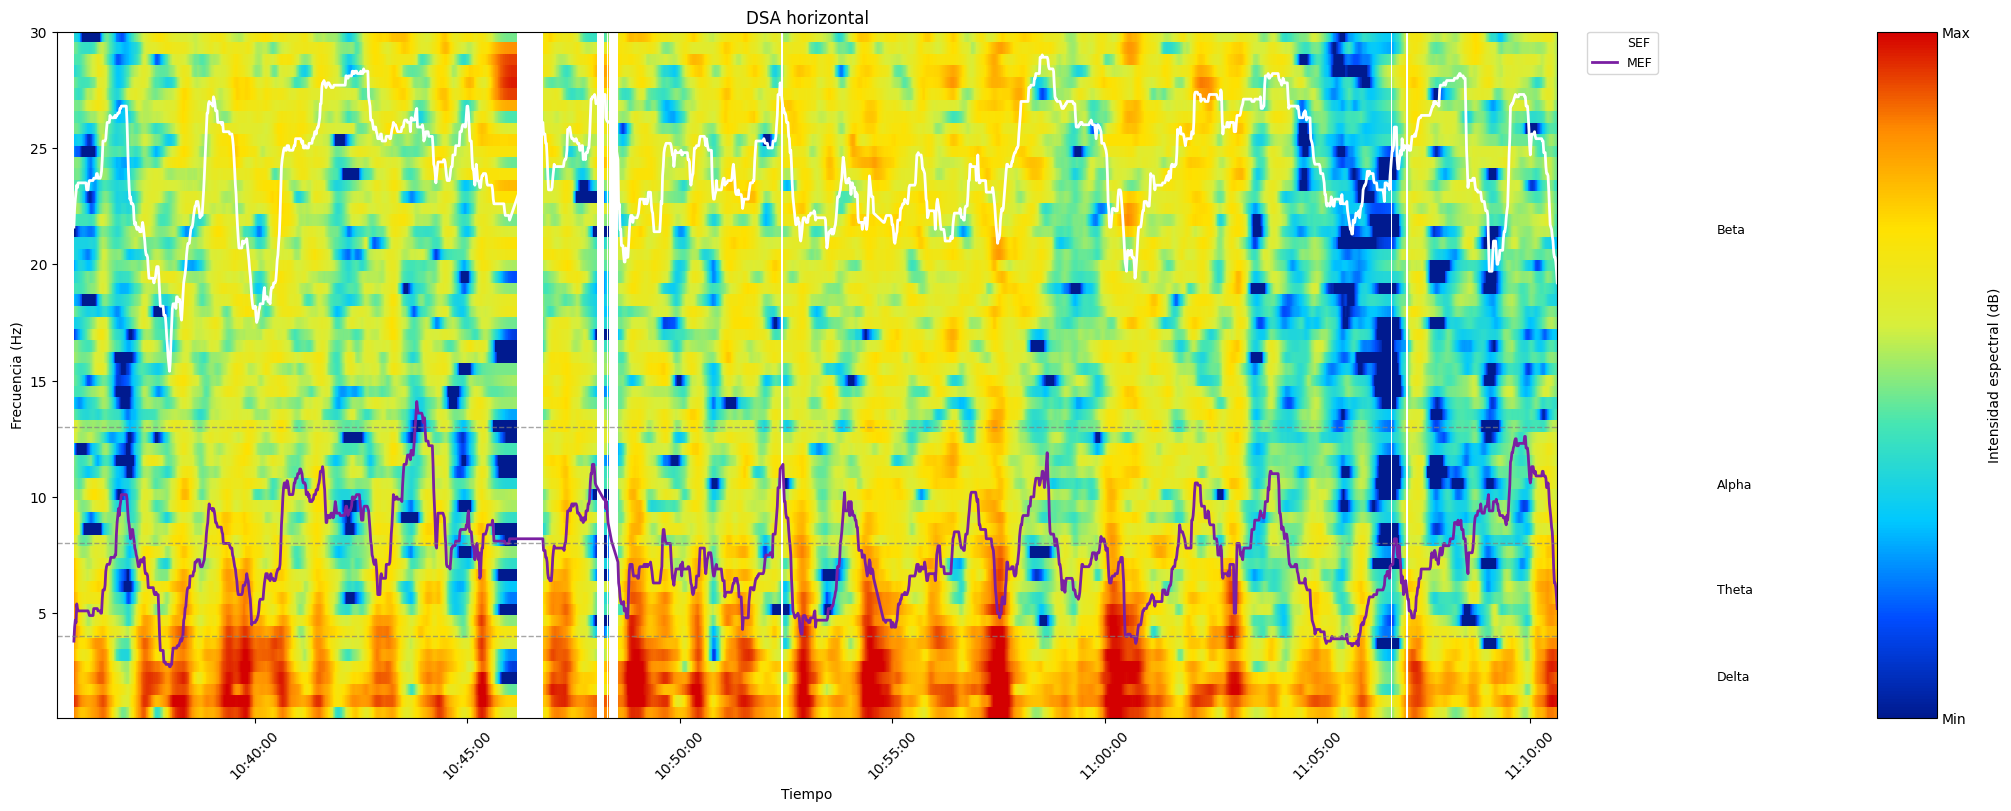

(<Figure size 2000x800 with 3 Axes>,
 <Axes: title={'center': 'DSA horizontal'}, xlabel='Tiempo', ylabel='Frecuencia (Hz)'>,
 <Axes: >,
 <Axes: ylabel='Intensidad espectral (dB)'>)

In [11]:
df_merge_hor = fun_dsa.alinear_spa_con_tiempo(tiempo_fa_unilat, df_spa_unilat)
sef_hor = df_merge_hor["SEF08"]
mf_hor = df_merge_hor["MEDFRQ08"]

dsa_plot_hor, mask_total_hor = fun_dsa.preparar_dsa_para_plot(tiempo_fa_unilat, dsa_unilat, df_merge_hor)
matriz_hor, vmin, vmax, norm, cmap = fun_dsa.preparar_escala_color_dsa(dsa_plot_hor)
fun_dsa.plot_dsa_horizontal(dsa_plot_hor=dsa_plot_hor, tiempo=tiempo_fa_unilat, sef_hor=sef_hor, mf_hor=mf_hor, titulo="DSA horizontal")

# Procesado

In [12]:
archivo_r2a = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

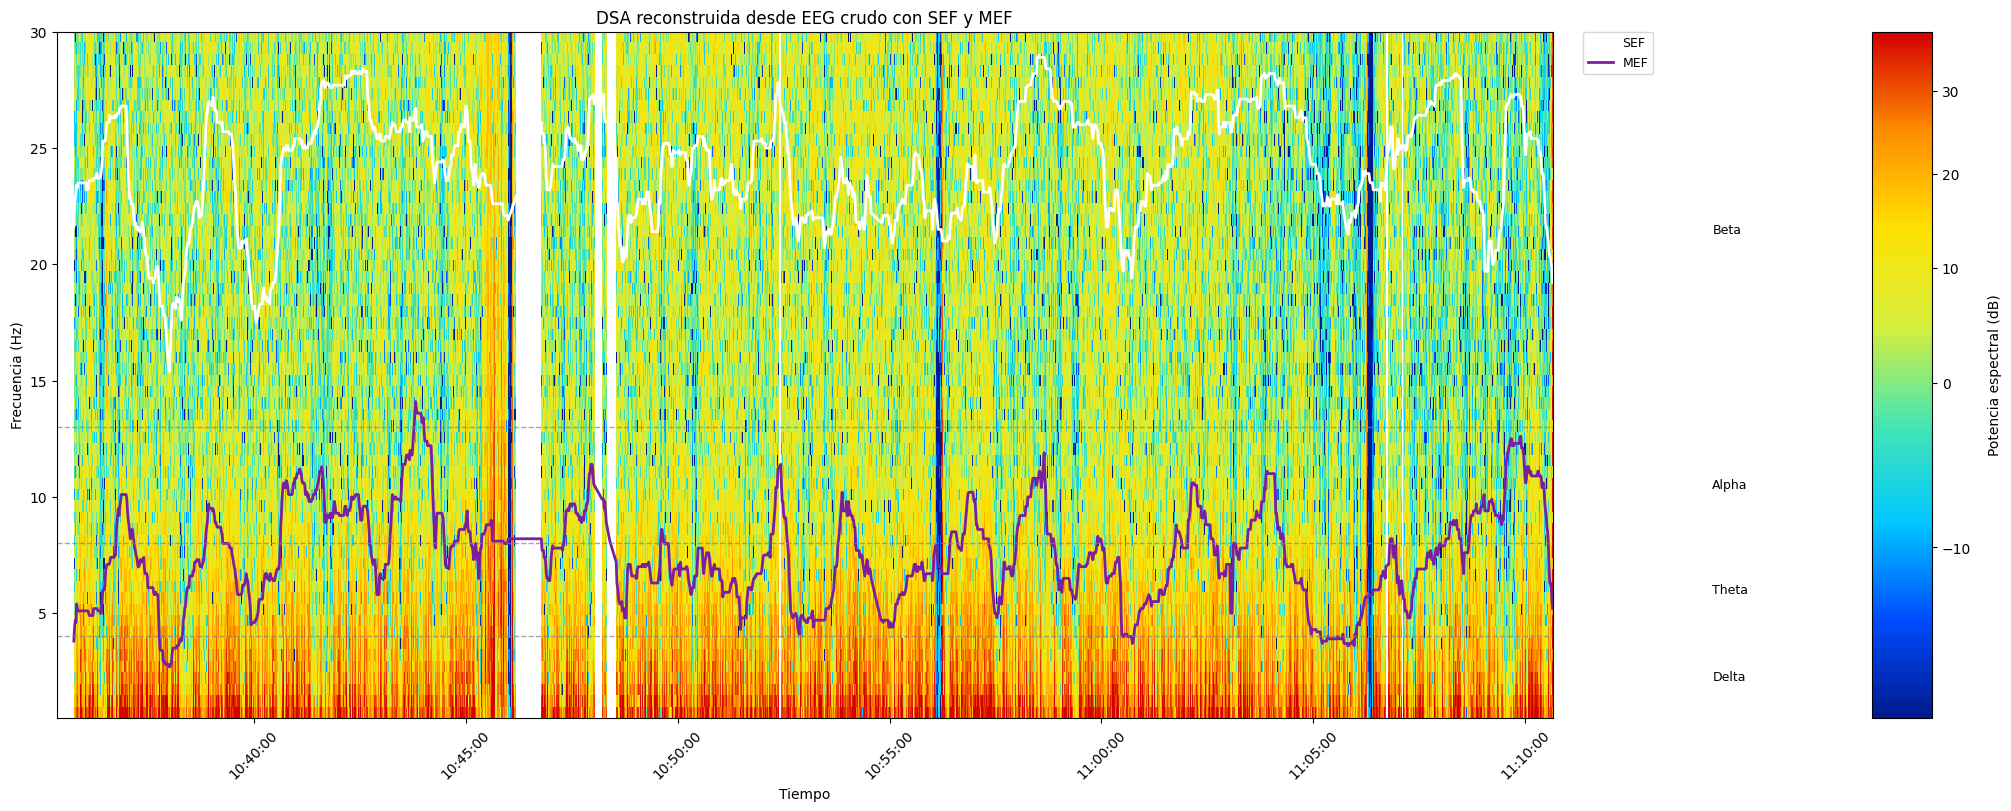

In [13]:
# 1. Leer EEG crudo
df_eeg = fun_dsa.leer_r2a(
    archivo_r2a,
    fs=128,
    escala_uv=0.0511
)

# 2. Crear matriz DSA mediante FFT/Welch
df_dsa, frecuencias = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg,
    fs=128,
    canal="canal_1_uV",
    ventana_seg=2,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="db",
    tiempo_referencia="centro"
)

# 3. Asegurar que el .spa tiene Time como datetime

df_spa_unilat, hora_inicio = fun_dsa.obtener_hora_inicio_desde_spa(df_spa_unilat)

# 4. Adaptar al formato esperado por tus funciones
tiempo_eeg, dsa_eeg = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa,
    frecuencias=frecuencias,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=True
)

# 5. Alinear SPA con tiempos de la DSA
df_merge_plot = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo_eeg,
    df_spa=df_spa_unilat
)

# 6. Preparar DSA con máscaras blancas
dsa_plot, mask_total = fun_dsa.preparar_dsa_para_plot(
    tiempo=tiempo_eeg,
    dsa=dsa_eeg,
    df_merge=df_merge_plot,
    umbral_sqi=14,
    umbral_ceros=0.9
)

# 7. Preparar escala de color tipo BIS
matriz_eeg, vmin, vmax, norm, cmap = fun_dsa.preparar_escala_color_dsa(
    dsa_plot,
    gamma=0.55
)

# 6. Dibujar DSA con SEF y MEF
fig, ax, ax_band, cax = fun_dsa.plot_dsa_con_sef_mef(
    tiempo=tiempo_eeg,
    frecuencias=frecuencias,
    matriz=matriz_eeg,
    norm=norm,
    cmap=cmap,
    df_merge=df_merge_plot,
    titulo="DSA reconstruida desde EEG crudo con SEF y MEF"
)